# Lab 3 - Part 1: Analyzing the Impact of Padding and Strides in CNNs

**Objective:** Experiment with CNN layers to understand how `padding` and `stride` parameters influence:
- Feature extraction and spatial dimensions
- Computational efficiency and model parameters
- Overall model accuracy and training speed

**Dataset:** MNIST (28x28 grayscale handwritten digits)

## Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Step 2: Load and Preprocess MNIST Dataset

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape : (60000, 28, 28, 1)
Test data shape     : (10000, 28, 28, 1)


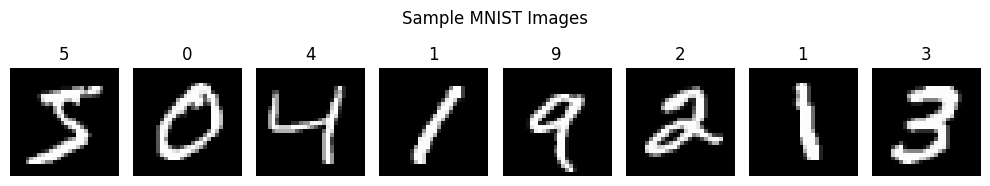

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Reshape to add channel dimension (28,28) -> (28,28,1) for grayscale
# Normalize pixel values from [0,255] to [0,1]
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode labels (0-9 -> 10-dim vector)
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test,  10)

print(f"Training data shape : {x_train.shape}")
print(f"Test data shape     : {x_test.shape}")

# Visualize a few sample images
plt.figure(figsize=(10, 2))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.title(str(np.argmax(y_train[i])))
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

## Step 3: Understand the Effect of Padding and Strides (Theory)

**Padding:**
- `'valid'` — No padding. Output shrinks: `(28-3)/1 + 1 = 26x26`
- `'same'`  — Zero-pad borders. Output stays same size: `28x28`

**Strides:**
- `stride=1` — Move kernel 1 pixel at a time (fine-grained, more operations)
- `stride=2` — Skip every other position (coarser, 4x fewer operations)

**Output size formula:** `floor((H - K + 2P) / S) + 1`
where H=input, K=kernel, P=padding, S=stride

## Step 4: Define Experiment Configurations

In [3]:
# Four configurations to compare
configs = [
    {"padding": "valid", "stride": 1, "name": "Valid | Stride 1"},
    {"padding": "same",  "stride": 1, "name": "Same  | Stride 1"},
    {"padding": "valid", "stride": 2, "name": "Valid | Stride 2"},
    {"padding": "same",  "stride": 2, "name": "Same  | Stride 2"},
]

print("Experiment configurations:")
for c in configs:
    print(f"  - {c['name']}")

Experiment configurations:
  - Valid | Stride 1
  - Same  | Stride 1
  - Valid | Stride 2
  - Same  | Stride 2


## Step 5: Build and Run All Experiments

In [4]:
results = []
feature_maps_to_plot = []

# Use a single test image to visualize feature maps later
sample_digit = x_test[0:1]  # shape: (1, 28, 28, 1)

print("Starting experiments...\n")

for config in configs:
    print(f"{'='*50}")
    print(f"Running: {config['name']}")
    print(f"{'='*50}")

    # ── Build Model ──────────────────────────────────────────────
    inputs = layers.Input(shape=(28, 28, 1))

    # The KEY layer we are experimenting with
    conv_out = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding=config['padding'],
        strides=config['stride'],
        activation='relu',
        name='target_conv'
    )(inputs)

    # Intermediate model to extract the feature maps (for visualization)
    intermediate_model = keras.Model(inputs=inputs, outputs=conv_out)

    # Complete classification model
    x = layers.MaxPooling2D((2, 2))(conv_out)
    x = layers.Flatten()(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    # ── Capture Feature Map Dimensions ───────────────────────────
    maps = intermediate_model.predict(sample_digit, verbose=0)
    out_shape = maps.shape[1:3]  # (height, width)
    params = model.count_params()
    print(f"  Feature map output size : {out_shape[0]}x{out_shape[1]}")
    print(f"  Total parameters        : {params:,}")

    # ── Train (brief, 2 epochs for speed) ────────────────────────
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    model.fit(x_train, y_train,
              epochs=2,
              batch_size=256,
              verbose=1)
    train_time = round(time.time() - start, 2)

    _, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "Config"      : config['name'],
        "Output Dim"  : f"{out_shape[0]}x{out_shape[1]}",
        "Params"      : params,
        "Time (s)"    : train_time,
        "Accuracy"    : round(acc, 4)
    })
    feature_maps_to_plot.append((maps, config['name']))

print("\nAll experiments completed!")

Starting experiments...

Running: Valid | Stride 1
  Feature map output size : 26x26
  Total parameters        : 54,410
Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.8776 - loss: 0.4730
Epoch 2/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.9533 - loss: 0.1669
Running: Same  | Stride 1
  Feature map output size : 28x28
  Total parameters        : 63,050
Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - accuracy: 0.8843 - loss: 0.4635
Epoch 2/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.9559 - loss: 0.1543
Running: Valid | Stride 2
  Feature map output size : 13x13
  Total parameters        : 11,850
Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8145 - loss: 0.7536
Epoch 2/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9258 - loss: 0.2590
Running: Same  | Stride 2
  Feature map output size : 14x14
  Total parameters        : 16,010
Epoch 1/2
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8216 - l

## Step 6: Summary Table

In [5]:
df_results = pd.DataFrame(results)

print("\n" + "="*60)
print("         EXPERIMENT SUMMARY TABLE")
print("="*60)
print(df_results.to_string(index=False))
print("="*60)


         EXPERIMENT SUMMARY TABLE
          Config Output Dim  Params  Time (s)  Accuracy
Valid | Stride 1      26x26   54410     40.54    0.9675
Same  | Stride 1      28x28   63050     47.17    0.9668
Valid | Stride 2      13x13   11850     10.84    0.9445
Same  | Stride 2      14x14   16010     17.36    0.9463


## Step 7: Visualize Feature Maps (Padding & Stride Impact)

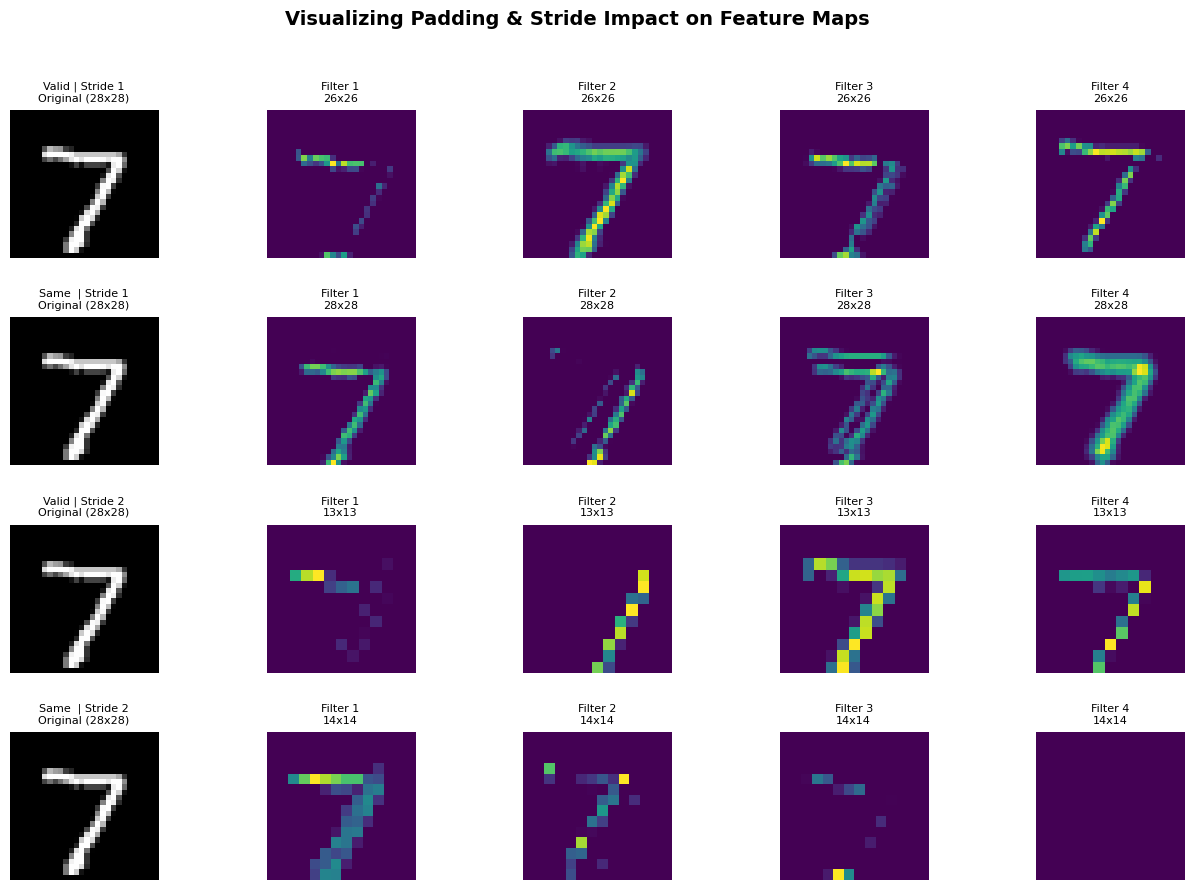

Figure saved as 'feature_maps.png'


In [6]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4)

for i, (maps, name) in enumerate(feature_maps_to_plot):
    # Column 0: Original input image
    axes[i, 0].imshow(sample_digit[0, :, :, 0], cmap='gray')
    axes[i, 0].set_title(f"{name}\nOriginal (28x28)", fontsize=8)
    axes[i, 0].axis('off')

    # Columns 1-4: First 4 filter activations
    for j in range(1, 5):
        axes[i, j].imshow(maps[0, :, :, j], cmap='viridis')
        axes[i, j].set_title(f"Filter {j}\n{maps.shape[1]}x{maps.shape[2]}", fontsize=8)
        axes[i, j].axis('off')

plt.suptitle("Visualizing Padding & Stride Impact on Feature Maps",
             fontsize=14, y=0.98, fontweight='bold')
plt.savefig('feature_maps.png', bbox_inches='tight', dpi=100)
plt.show()
print("Figure saved as 'feature_maps.png'")

## Step 8: Bar Chart Comparison

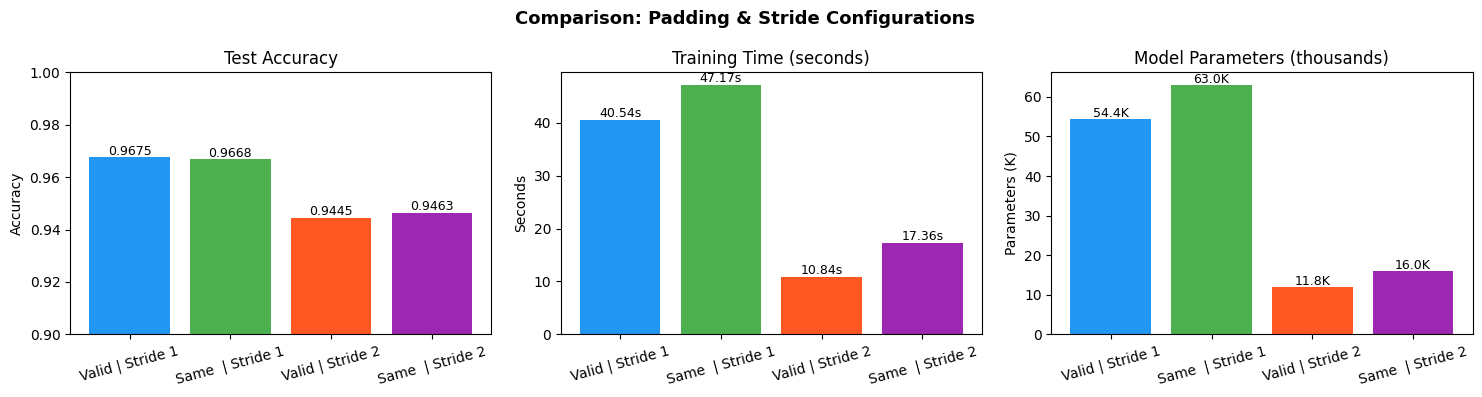

Figure saved as 'comparison_chart.png'


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

names = [r['Config'] for r in results]
accs  = [r['Accuracy'] for r in results]
times = [r['Time (s)'] for r in results]
params_k = [r['Params'] / 1000 for r in results]  # in thousands

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

# Accuracy
axes[0].bar(names, accs, color=colors)
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.9, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[0].patches, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{v:.4f}', ha='center', fontsize=9)

# Training Time
axes[1].bar(names, times, color=colors)
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[1].patches, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v}s', ha='center', fontsize=9)

# Parameters
axes[2].bar(names, params_k, color=colors)
axes[2].set_title('Model Parameters (thousands)')
axes[2].set_ylabel('Parameters (K)')
axes[2].tick_params(axis='x', rotation=15)
for bar, v in zip(axes[2].patches, params_k):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}K', ha='center', fontsize=9)

plt.suptitle('Comparison: Padding & Stride Configurations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_chart.png', bbox_inches='tight', dpi=100)
plt.show()
print("Figure saved as 'comparison_chart.png'")

## Step 9: Analysis and Observations

### Key Findings:

| Configuration | Output Size | Effect |
|---|---|---|
| Valid + Stride 1 | 26x26 | Slight info loss at edges, high resolution |
| Same + Stride 1 | 28x28 | Preserves all spatial info, more params |
| Valid + Stride 2 | 13x13 | Aggressive downsampling, fastest training |
| Same + Stride 2 | 14x14 | Balanced: downsamples while preserving edges |

### Conclusions:
- **Same padding + Stride 1** gives the best accuracy but uses more memory
- **Higher strides** reduce training time significantly (fewer operations)
- **Valid padding** slightly reduces feature map size, losing border information
- For **classification tasks**, stride-2 is often used as an efficient alternative to pooling layers
- For **segmentation tasks**, same padding + stride 1 is preferred to preserve spatial detail